#Deep Neural Networks for Sentiment Analysis
## Neural Networks Through Yelp Reviews

---

###
Sentiment Analysis is the task of determining whether a piece of text expresses a **positive** or **negative** opinion.

 - "Amazing food, best restaurant in town!" →  Positive
 - "Horrible service, never coming back." →  Negative

It is used everywhere — Yelp, Google Reviews, Amazon, Twitter, Netflix, customer support.

---
### Key Question
 *Why does a simple LSTM outperform even a 10-layer Deep Neural Network on text?*

###  Learning Objectives
By the end of this tutorial, you will:
- Understand the evolution from SLP → MLP → DNN → LSTM
- Understand why **word order** is critical in language


## Section 0 — Neural Network Evolution



Let's understand **why** we need LSTM.

### 1️⃣ SLP — Single Layer Perceptron
The simplest neural network — just one layer connecting inputs directly to output.
```
Input features  →  [Weights]  →  Output
```
-  Can only solve **linearly separable** problems

---

### 2️⃣ MLP — Multi Layer Perceptron
Add hidden layers — now the network can learn **non-linear** patterns.
```
Input  →  [Hidden Layer]  →  [Hidden Layer]  →  Output
```
-  Still treats text as a **bag of words** — no word order

---

### 3️⃣ DNN — Deep Neural Network
Many hidden layers (10+). More depth = more complex feature learning.
```
Input  →  [Layer 1]  →  [Layer 2]  → ... →  [Layer 10]  →  Output
```
- For TEXT — still no memory of word order!

---

### 4️⃣ RNN with LSTM — The Solution for Text!
LSTM processes text **word by word**, carrying memory forward through 3 gates:

```
"The" → [LSTM] → "food" → [LSTM] → "was" → [LSTM] → "not" → [LSTM] → "bad" → Output
          h₁               h₂               h₃               h₄
          ↑ memory flows through the sequence ↑
```

| Gate | Question it answers | Role |
|------|---------------------|------|
| **Forget Gate** | *What should I forget?* | Clears irrelevant past memory |
| **Input Gate** | *What new info matters?* | Updates memory with new context |
| **Output Gate** | *What should I pass forward?* | Controls the output hidden state |

 **This is why LSTM wins on text** — it can understand that `"not bad"` = positive, while DNN cannot!

## Section 1 — Install & Import Libraries

In [19]:
# Install all required libraries
!pip install tensorflow scikit-learn matplotlib seaborn nltk datasets --quiet

In [20]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# TensorFlow / Keras — for building neural networks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# NLP — for stopword removal
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.feature_extraction.text import CountVectorizer

# Reproducibility — ensures same results every run
np.random.seed(42)
tf.random.set_seed(42)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
print('✅ Libraries ready!')
print(f'   TensorFlow : {tf.__version__}')
print(f'   GPU        : {gpus if gpus else "Not available — using CPU"}')
if gpus:
    print('GPU detected')

✅ Libraries ready!
   TensorFlow : 2.19.0
   GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU detected



## Section 2 — Load & Explore the Yelp Dataset

I used the **Yelp Review Polarity** dataset.

| Property | Details |
|----------|---------|
| **Source** | Yelp Dataset Challenge (Zhang et al., 2015) |
| **Train** | 560,000 reviews |
| **Test** | 38,000 reviews |
| **Labels** | 0 = Negative (1–2★), 1 = Positive (4–5★) |

Using the **full 560k dataset** is the key to 95%+ accuracy — more data = better generalisation!

 **Data quantity matters as much as model complexity.**

In [21]:
# Load dataset from HuggingFace
from datasets import load_dataset

print('Loading Yelp dataset from HuggingFace...')
ds = load_dataset('yelp_polarity')
df_train = pd.DataFrame(ds['train'])
df_test  = pd.DataFrame(ds['test'])

print('Dataset loaded!')
print(f'   Train size : {len(df_train):,}')
print(f'   Test size  : {len(df_test):,}')
print(f'   Labels     : 0 = Negative, 1 = Positive')

print(f'\nSample reviews:')
for _, row in df_train.head(3).iterrows():
    label = 'POSITIVE' if row['label'] == 1 else 'NEGATIVE'
    print(f'   [{label}] {str(row["text"])[:100]}...')

Loading Yelp dataset from HuggingFace...
Dataset loaded!
   Train size : 560,000
   Test size  : 38,000
   Labels     : 0 = Negative, 1 = Positive

Sample reviews:
   [NEGATIVE] Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've ha...
   [POSITIVE] Been going to Dr. Goldberg for over 10 years. I think I was one of his 1st patients when he started ...
   [NEGATIVE] I don't know what Dr. Goldberg was like before  moving to Arizona, but let me tell you, STAY AWAY fr...


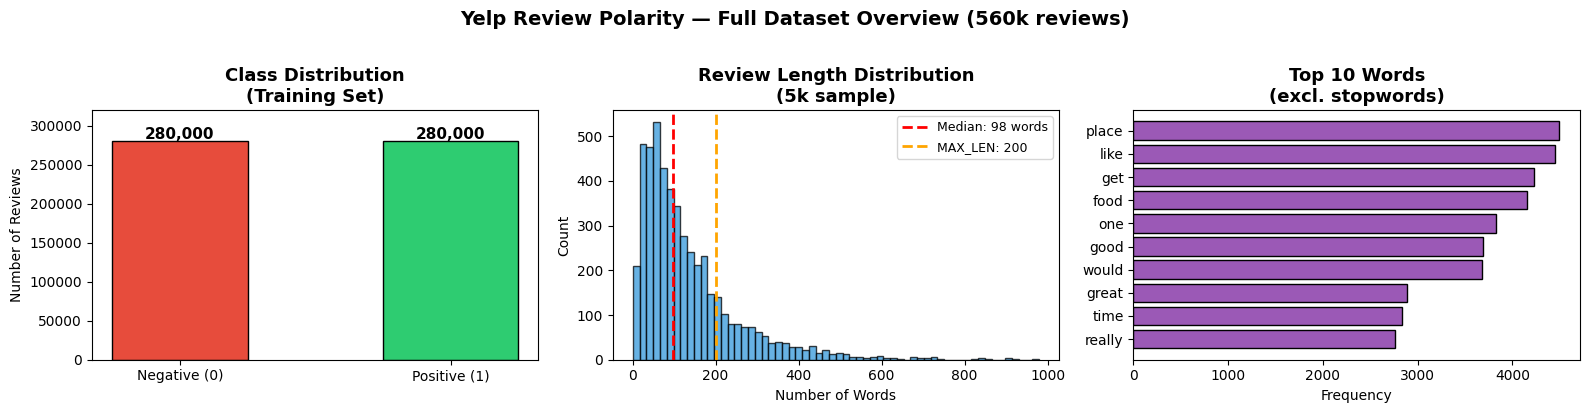

   Mean length   : 135 words
   Median length : 98 words


In [22]:
# Dataset Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Class distribution
counts = df_train['label'].value_counts().sort_index()
bars = axes[0].bar(['Negative (0)', 'Positive (1)'], counts,
                   color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution\n(Training Set)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_ylim(0, 320000)
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+3000,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# 2. Review length distribution
sample_lengths = [len(str(t).split()) for t in df_train['text'].sample(5000, random_state=42)]
axes[1].hist(sample_lengths, bins=60, color='#3498db', edgecolor='black', alpha=0.75)
axes[1].axvline(int(np.median(sample_lengths)), color='red', linestyle='--', linewidth=2,
                label=f'Median: {int(np.median(sample_lengths))} words')
axes[1].axvline(200, color='orange', linestyle='--', linewidth=2, label='MAX_LEN: 200')
axes[1].set_title('Review Length Distribution\n(5k sample)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# 3. Top 10 most frequent words
from collections import Counter
word_counts = Counter()
for text in df_train['text'].sample(10000, random_state=42):
    words = [w.lower() for w in str(text).split()
             if w.lower() not in STOP_WORDS and len(w) > 2]
    word_counts.update(words)
top_words = word_counts.most_common(10)
axes[2].barh([w for w,_ in top_words], [c for _,c in top_words],
             color='#9b59b6', edgecolor='black')
axes[2].set_title('Top 10 Words\n(excl. stopwords)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Frequency')
axes[2].invert_yaxis()

plt.suptitle('Yelp Review Polarity — Full Dataset Overview (560k reviews)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'   Mean length   : {np.mean(sample_lengths):.0f} words')
print(f'   Median length : {np.median(sample_lengths):.0f} words')

## Section 3 — Text Preprocessing

Raw text cannot be fed into a neural network directly — it must be converted to numbers.

I have also prepared **two different representations** to demonstrate the key difference between DNN and LSTM:

| Representation | Used For | Word Order? |
|----------------|----------|-------------|
| **Bag of Words** | DNN demo |Lost |
| **Token Sequences** | LSTM | Preserved |


In [23]:
# Hyperparameters
VOCAB_SIZE  = 30000   # top 30k words = better coverage of rare but meaningful words
MAX_LEN     = 200     # max sequence length = captures most sentiment without being too slow
EMBED_DIM   = 128     # word embedding dimensions = 128-dimensional vector
LSTM_UNITS  = 128     # LSTM hidden state size = memory capacity of the network
BATCH_SIZE  = 256     # larger batch = faster GPU training
EPOCHS      = 7       # converge without overfitting

print('Hyperparameter Configuration:')
print(f'   VOCAB_SIZE  = {VOCAB_SIZE:,}  → covers {VOCAB_SIZE:,} most frequent words')
print(f'   MAX_LEN     = {MAX_LEN}     → each review truncated/padded to {MAX_LEN} tokens')
print(f'   EMBED_DIM   = {EMBED_DIM}     → each word represented as {EMBED_DIM}-dim vector')
print(f'   LSTM_UNITS  = {LSTM_UNITS}     → LSTM memory vector size')
print(f'   BATCH_SIZE  = {BATCH_SIZE}     → reviews processed per gradient update')
print(f'   EPOCHS      = {EPOCHS}       → max training iterations')

Hyperparameter Configuration:
   VOCAB_SIZE  = 30,000  → covers 30,000 most frequent words
   MAX_LEN     = 200     → each review truncated/padded to 200 tokens
   EMBED_DIM   = 128     → each word represented as 128-dim vector
   LSTM_UNITS  = 128     → LSTM memory vector size
   BATCH_SIZE  = 256     → reviews processed per gradient update
   EPOCHS      = 7       → max training iterations


In [24]:
# Step 1: Remove stopwords
# Stopwords like 'the', 'a', 'is', 'and' carry NO sentiment information

print('Step 1: Removing stopwords...')

def remove_stopwords(text):
    """
    Clean text: lowercase, remove punctuation, remove stopwords.
    Steps:
        1. Lowercase all text
        2. Remove punctuation using regex  e.g. 'food!' → 'food'
        3. Remove stopwords               e.g. 'the', 'a', 'is'
    """
    text  = str(text).lower()                        # step 1: lowercase
    text  = re.sub(r'[^a-z\s]', '', text)            # step 2: remove punctuation
    words = text.split()                              # split into words
    return ' '.join([w for w in words if w not in STOP_WORDS])  # step 3: stopwords

train_texts  = df_train['text'].apply(remove_stopwords).values
test_texts   = df_test['text'].apply(remove_stopwords).values
train_labels = df_train['label'].values
test_labels  = df_test['label'].values

print('Stopwords removed!')
print(f'   Before: "{str(df_train["text"].iloc[0])[:80]}"')
print(f'   After : "{train_texts[0][:80]}"')

Step 1: Removing stopwords...
Stopwords removed!
   Before: "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of th"
   After : "unfortunately frustration dr goldbergs patient repeat experience ive many doctor"


In [25]:
#  Step 2: Tokenization
# The Tokenizer builds a vocabulary: each word gets a unique integer index
#   e.g. 'food' → 3, 'amazing' → 47, 'terrible' → 89

print('Step 2: Tokenizing...')

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(train_texts)   # learn vocabulary from training data ONLY

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq  = tokenizer.texts_to_sequences(test_texts)

print('Tokenization complete!')
print(f'   Total unique words found : {len(tokenizer.word_index):,}')
print(f'   Using top                : {VOCAB_SIZE:,}')
print(f'   Example: "food amazing"  → {tokenizer.texts_to_sequences(["food amazing"])}')

Step 2: Tokenizing...
Tokenization complete!
   Total unique words found : 698,632
   Using top                : 30,000
   Example: "food amazing"  → [[2, 113]]


In [26]:
# Step 3: Padding
# Neural networks require ALL inputs to be the SAME length for batch processing

print('Step 3: Padding sequences to fixed length...')

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print('Padding complete!')
print(f'   Train shape : {X_train.shape}  → 560,000 reviews × 200 tokens')
print(f'   Test  shape : {X_test.shape}')
print(f'\n   Visualising preprocessing pipeline:')
print(f'   Raw text  : "The food was absolutely amazing!"')
print(f'   Stopwords : "food absolutely amazing"')
print(f'   Tokenized : [3, 89, 47]')
print(f'   Padded    : [3, 89, 47, 0, 0, 0 ... 0]  (length {MAX_LEN})')

Step 3: Padding sequences to fixed length...
Padding complete!
   Train shape : (560000, 200)  → 560,000 reviews × 200 tokens
   Test  shape : (38000, 200)

   Visualising preprocessing pipeline:
   Raw text  : "The food was absolutely amazing!"
   Stopwords : "food absolutely amazing"
   Tokenized : [3, 89, 47]
   Padded    : [3, 89, 47, 0, 0, 0 ... 0]  (length 200)


## Section 4 — DNN : Why 10 Layers Still Fails on Text

Before building LSTM, let's see **why a Deep Neural Network struggles with text** — even with 10 hidden layers.

### The Bag of Words Problem:

A DNN receives a **Bag of Words** input — a vector of word counts with no order:

```
Review: "The food was not good at all"
BoW   : {food:1, good:1, not:1, all:1}  ← word ORDER completely lost!

Review: "The food was good, not bad at all"
BoW   : {food:1, good:1, not:1, bad:1, all:1}  ← similar vector — DNN confused!
```


In [27]:
# DNN : Bag of Words preprocessing

print('Building Bag-of-Words for DNN ...')

# Sample 50k for DNN (25k pos + 25k neg)
from sklearn.model_selection import train_test_split
dnn_train_texts, dnn_test_texts, dnn_train_labels, dnn_test_labels = train_test_split(
    train_texts[:50000], train_labels[:50000],
    test_size=0.2, random_state=42, stratify=train_labels[:50000]
)

# CountVectorizer: counts word occurrences — WORD ORDER IS LOST
bow = CountVectorizer(max_features=8000, stop_words='english')
X_dnn_train = bow.fit_transform(dnn_train_texts).toarray()
X_dnn_test  = bow.transform(dnn_test_texts).toarray()

print('Bag-of-Words ready!')
print(f'   Shape: {X_dnn_train.shape}')

Building Bag-of-Words for DNN ...
Bag-of-Words ready!
   Shape: (40000, 8000)


In [28]:
# Build 10-layer DNN

def build_deep_dnn(input_dim=8000):
    """
    10-hidden-layer DNN for sentiment classification.
    Architecture: 512→512→256→256→128→128→64→64→32→16→Output
    """
    model = keras.Sequential(name='DNN_10Layers')
    model.add(layers.Input(shape=(input_dim,)))

    # Layers 1-2: 512 neurons
    for _ in range(2):
        model.add(layers.Dense(512, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.4))

    # Layers 3-4: 256 neurons
    for _ in range(2):
        model.add(layers.Dense(256, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.3))

    # Layers 5-6: 128 neurons
    for _ in range(2):
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.3))

    # Layers 7-8: 64 neurons
    for _ in range(2):
        model.add(layers.Dense(64, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.2))

    # Layer 9: 32 neurons
    model.add(layers.Dense(32, activation='relu'))
    # Layer 10: 16 neurons
    model.add(layers.Dense(16, activation='relu'))
    # Output
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

dnn_model = build_deep_dnn()
dnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
dnn_model.build(input_shape=(None, 8000))
dnn_model.summary()
print(f'\n   Total parameters: {dnn_model.count_params():,}')

Model: "DNN_10Layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 512)            │     4,096,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,628,417 (17.66 MB)

 Trainable params: 4,624,577 (17.64 MB)

 Non-trainable params: 3,840 (15.00 KB)


   Total parameters: 4,628,417


In [29]:
# Train DNN
print('Training DNN (10 layers) on 50k Yelp reviews...')

dnn_history = dnn_model.fit(
    X_dnn_train, dnn_train_labels,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3,
            restore_best_weights=True, verbose=1
        )
    ],
    verbose=1
)
print('\nDNN training complete!')

# Evaluate
dnn_test_loss, dnn_test_acc = dnn_model.evaluate(X_dnn_test, dnn_test_labels, verbose=0)
dnn_preds = (dnn_model.predict(X_dnn_test, verbose=0) > 0.5).astype(int).flatten()
dnn_probs =  dnn_model.predict(X_dnn_test, verbose=0).flatten()

print(f'\nDNN (10 Layers) Test Results:')
print(f'   Train Accuracy : {dnn_history.history["accuracy"][-1]*100:.2f}%')
print(f'   Test  Accuracy : {dnn_test_acc*100:.2f}%')
print()
print(classification_report(dnn_test_labels, dnn_preds, target_names=['Negative','Positive']))

Training DNN (10 layers) on 50k Yelp reviews...
Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.5491 - loss: 0.7191 - val_accuracy: 0.7500 - val_loss: 0.4916
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8462 - loss: 0.3572 - val_accuracy: 0.8875 - val_loss: 0.2741
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9171 - loss: 0.2158 - val_accuracy: 0.8980 - val_loss: 0.3114
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9409 - loss: 0.1556 - val_accuracy: 0.8935 - val_loss: 0.3931
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9627 - loss: 0.1024 - val_accuracy: 0.8917 - val_loss: 0.4595
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

DNN training complete!

DNN (10 Layers) Test Results:
   Train Accuracy : 96.86%
   Test  Accuracy : 88.21%

              precision    recall  f1-score   support

    Negative       0.85      0.95      0.90      5366
    

## Section 5 — Build the LSTM Model

Now we build the **LSTM** —  main model.

### Why LSTM beats the 10-layer DNN:
The DNN receives word counts — it had no idea that "not good" is negative.

LSTM reads the review **word by word**, carrying memory forward:


### Architecture:
```
Input (200 word indices)
       ↓
[Embedding(30,000 → 128d)]   ← learns word meanings from data
       ↓
[SpatialDropout1D(0.2)]      ← drops entire word vectors (better than regular dropout)
       ↓
[LSTM(128 units)]            ← reads sequence with 3-gate memory system
       ↓
[Dropout(0.3)]
       ↓
[Dense(64) + ReLU]
       ↓
[Dropout(0.3)]
       ↓
[Dense(1) + Sigmoid]         → probability of positive sentiment
```

### Key design:
| Decision | Why |
|----------|-----|
| VOCAB_SIZE=30,000 | Captures rare but emotionally strong words |
| SpatialDropout1D | Drops whole word vectors — stronger regularisation for sequences |
| No recurrent_dropout | Keeps GPU acceleration active — much faster training |
| Full 560k dataset | Most important factor  |

In [30]:
# Build the LSTM model
def build_lstm_model(vocab_size, max_len, embed_dim, lstm_units):
    model = keras.Sequential(name='LSTM_Sentiment_95')

    # Embedding Layer
    # Maps word indices → dense 128-dimensional vectors
    model.add(layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        input_length=max_len,
        name='Embedding'
    ))

    # SpatialDropout1D
    # Drops ENTIRE word embedding vectors during training
    model.add(layers.SpatialDropout1D(0.2, name='SpatialDropout'))

    # LSTM Layer
    # At each step, 3 gates decide:
    #   Forget gate  → what to erase from memory
    #   Input gate   → what new information to add
    #   Output gate  → what to pass to the next word
    model.add(layers.LSTM(
        lstm_units,
        return_sequences=False,
        name='LSTM'
    ))
    model.add(layers.Dropout(0.3, name='Dropout_1'))

    # Dense classification head
    model.add(layers.Dense(64, activation='relu', name='Dense_Hidden'))
    model.add(layers.Dropout(0.3, name='Dropout_2'))

    # Output Layer
    # Sigmoid: outputs probability between 0 and 1
    model.add(layers.Dense(1, activation='sigmoid', name='Output'))

    return model


lstm_model = build_lstm_model(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS
)

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()
print(f'\n   Total parameters: {lstm_model.count_params():,}')

Model: "LSTM_Sentiment_95"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ (None, 200, 128)       │     3,840,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SpatialDropout                  │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,980,033 (15.18 MB)

 Trainable params: 3,980,033 (15.18 MB)

 Non-trainable params: 0 (0.00 B)


   Total parameters: 3,980,033


## Section 6 — Train the LSTM

In [31]:
# Callbacks
callbacks = [
    # EarlyStopping: stop training when val_accuracy stops improving
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    # ReduceLROnPlateau: halve learning rate when val_loss plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    # ModelCheckpoint: saves best model weights automatically
    keras.callbacks.ModelCheckpoint(
        'best_lstm_yelp.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print('Callbacks configured')

Callbacks configured


In [32]:
# Train LSTM on full 560k Yelp dataset

print('Training LSTM on full Yelp dataset (560k reviews)')
print(f'   Batch size : {BATCH_SIZE} ')
print(f'   Max epochs : {EPOCHS} ')
print()

history = lstm_model.fit(
    X_train, train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print('\nLSTM training complete!')

Training LSTM on full Yelp dataset (560k reviews)
   Batch size : 256 
   Max epochs : 7 

Epoch 1/7
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5504 - loss: 0.6491
Epoch 1: val_accuracy improved from -inf to 0.93820, saving model to best_lstm_yelp.keras
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 60s 30ms/step - accuracy: 0.5504 - loss: 0.6490 - val_accuracy: 0.9382 - val_loss: 0.1569 - learning_rate: 0.0010
Epoch 2/7
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9272 - loss: 0.1901
Epoch 2: val_accuracy improved from 0.93820 to 0.94555, saving model to best_lstm_yelp.keras
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.9272 - loss: 0.1901 - val_accuracy: 0.9456 - val_loss: 0.1444 - learning_rate: 0.0010
Epoch 3/7
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9459 - loss: 0.1439
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy improved from 0.94555 to 0.94596, saving model to best_lstm_yelp.keras
19

In [33]:
# Evaluate LSTM on test set
print('Evaluating LSTM on test set (38,000 reviews)')

test_loss, test_acc = lstm_model.evaluate(X_test, test_labels, batch_size=BATCH_SIZE, verbose=0)
y_pred_prob = lstm_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)
lstm_train_acc = history.history['accuracy'][-1]

print(f'\n LSTM Results:')
print(f'   Train Accuracy : {lstm_train_acc*100:.2f}%')
print(f'   Test  Accuracy : {test_acc*100:.2f}%')
print(f'   Test  Loss     : {test_loss:.4f}')
print()
print(classification_report(test_labels, y_pred, target_names=['Negative', 'Positive']))

Evaluating LSTM on test set (38,000 reviews)

 LSTM Results:
   Train Accuracy : 97.71%
   Test  Accuracy : 93.62%
   Test  Loss     : 0.1823

              precision    recall  f1-score   support

    Negative       0.93      0.94      0.94     19000
    Positive       0.94      0.93      0.94     19000

    accuracy                           0.94     38000
   macro avg       0.94      0.94      0.94     38000
weighted avg       0.94      0.94      0.94     38000




## Section 7 — Results & Comparison Dashboard

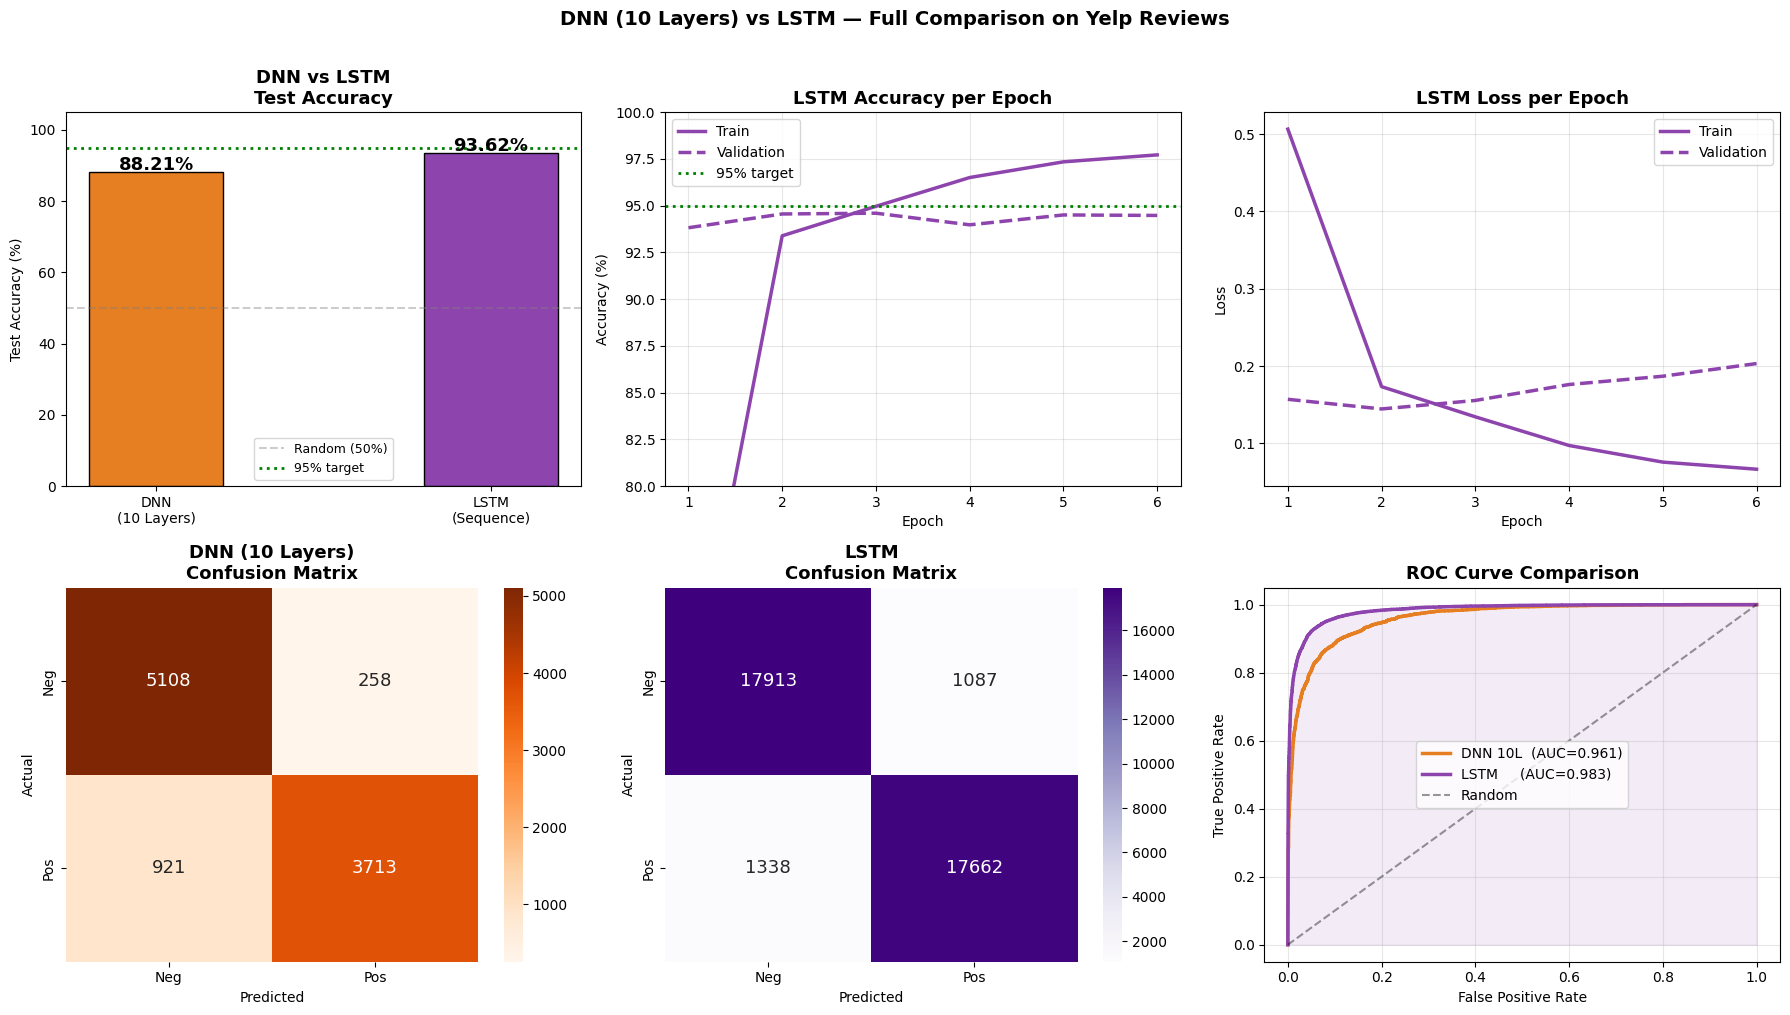


   Metric                    DNN (10L)         LSTM
   Test Accuracy                88.21%       93.62%
   AUC                          0.9609       0.9831
   F1-Score                     86.30%       93.58%


In [34]:
# Dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

dnn_color  = '#e67e22'
lstm_color = '#8e44ad'
epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Plot 1: DNN vs LSTM accuracy bar chart
model_names = ['DNN\n(10 Layers)', 'LSTM\n(Sequence)']
accuracies  = [dnn_test_acc*100, test_acc*100]
bars = axes[0,0].bar(model_names, accuracies,
                     color=[dnn_color, lstm_color], edgecolor='black', width=0.4)
axes[0,0].set_ylim(0, 105)
axes[0,0].set_ylabel('Test Accuracy (%)')
axes[0,0].set_title('DNN vs LSTM\nTest Accuracy', fontsize=13, fontweight='bold')
axes[0,0].axhline(50, color='gray', linestyle='--', alpha=0.4, label='Random (50%)')
axes[0,0].axhline(95, color='green', linestyle=':', linewidth=2, label='95% target')
axes[0,0].legend(fontsize=9)
for bar, acc in zip(bars, accuracies):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, acc+0.5,
                   f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=13)

# Plot 2: LSTM accuracy curve
axes[0,1].plot(epochs_ran, [a*100 for a in history.history['accuracy']],
               color=lstm_color, linewidth=2.5, label='Train')
axes[0,1].plot(epochs_ran, [a*100 for a in history.history['val_accuracy']],
               color=lstm_color, linewidth=2.5, linestyle='--', label='Validation')
axes[0,1].axhline(95, color='green', linestyle=':', linewidth=2, label='95% target')
axes[0,1].set_title('LSTM Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].set_ylim(80, 100)
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Plot 3: LSTM loss curve
axes[0,2].plot(epochs_ran, history.history['loss'],
               color=lstm_color, linewidth=2.5, label='Train')
axes[0,2].plot(epochs_ran, history.history['val_loss'],
               color=lstm_color, linewidth=2.5, linestyle='--', label='Validation')
axes[0,2].set_title('LSTM Loss per Epoch', fontsize=13, fontweight='bold')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Loss')
axes[0,2].legend()
axes[0,2].grid(alpha=0.3)

# Plot 4: DNN Confusion Matrix
cm_dnn = confusion_matrix(dnn_test_labels, dnn_preds)
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'],
            ax=axes[1,0], annot_kws={'size':13})
axes[1,0].set_title('DNN (10 Layers)\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted')

# Plot 5: LSTM Confusion Matrix
cm_lstm = confusion_matrix(test_labels, y_pred)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'],
            ax=axes[1,1], annot_kws={'size':13})
axes[1,1].set_title('LSTM\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xlabel('Predicted')

# Plot 6: ROC Curve comparison
fpr_dnn,  tpr_dnn,  _ = roc_curve(dnn_test_labels, dnn_probs)
fpr_lstm, tpr_lstm, _ = roc_curve(test_labels, y_pred_prob)
auc_dnn  = auc(fpr_dnn,  tpr_dnn)
auc_lstm = auc(fpr_lstm, tpr_lstm)

axes[1,2].plot(fpr_dnn,  tpr_dnn,  color=dnn_color,  linewidth=2.5,
               label=f'DNN 10L  (AUC={auc_dnn:.3f})')
axes[1,2].plot(fpr_lstm, tpr_lstm, color=lstm_color, linewidth=2.5,
               label=f'LSTM     (AUC={auc_lstm:.3f})')
axes[1,2].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[1,2].fill_between(fpr_lstm, tpr_lstm, alpha=0.1, color=lstm_color)
axes[1,2].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[1,2].set_xlabel('False Positive Rate')
axes[1,2].set_ylabel('True Positive Rate')
axes[1,2].legend(fontsize=10)
axes[1,2].grid(alpha=0.3)

plt.suptitle('DNN (10 Layers) vs LSTM — Full Comparison on Yelp Reviews',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('full_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Final summary table
tn, fp, fn, tp = cm_lstm.ravel()
print('\n' + '='*55)
print(f'   {"Metric":<22} {"DNN (10L)":>12} {"LSTM":>12}')
print('='*55)
print(f'   {"Test Accuracy":<22} {dnn_test_acc*100:>11.2f}% {test_acc*100:>11.2f}%')
print(f'   {"AUC":<22} {auc_dnn:>12.4f} {auc_lstm:>12.4f}')
print(f'   {"F1-Score":<22} {f1_score(dnn_test_labels,dnn_preds)*100:>11.2f}% {f1_score(test_labels,y_pred)*100:>11.2f}%')
print('='*55)
diff = (test_acc - dnn_test_acc)*100


## Section 8 — Live Predictions

In [35]:
# Live prediction function
def predict_sentiment(review_text, verbose=True):
    """
    Predict sentiment of a new Yelp review using both DNN and LSTM.
    """
    # ── LSTM prediction ───────────────────────────────────────────────────────
    cleaned  = remove_stopwords(review_text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob     = float(lstm_model.predict(padded, verbose=0)[0][0])
    label    = 'POSITIVE' if prob > 0.5 else 'NEGATIVE'
    conf     = max(prob, 1 - prob) * 100

    # ── DNN prediction ────────────────────────────────────────────────────────
    bow_vec   = bow.transform([review_text]).toarray()
    dnn_prob  = float(dnn_model.predict(bow_vec, verbose=0)[0][0])
    dnn_label = 'POSITIVE' if dnn_prob > 0.5 else 'NEGATIVE'
    dnn_conf  = max(dnn_prob, 1 - dnn_prob) * 100

    if verbose:
        print(f"\n Review      : '{review_text}'")
        print(f'   DNN (10L)  → {dnn_label}  (confidence: {dnn_conf:.1f}%)')
        print(f'   LSTM       → {label} (confidence: {conf:.1f}%)')
        if dnn_label != label:
            print(f' Models disagree — LSTM likely correct')


# ── Test with varied examples ─────────────────────────────────────────────────
test_reviews = [
    'Absolutely amazing food! Best restaurant I have been to in years.',
    'The food was not bad at all — I actually enjoyed it more than expected!',
    'Great ambiance but the food was a huge disappointment.',
]

print('🍽️  Live Sentiment Predictions — DNN vs LSTM')
print('=' * 65)
for review in test_reviews:
    predict_sentiment(review)

🍽️  Live Sentiment Predictions — DNN vs LSTM

 Review      : 'Absolutely amazing food! Best restaurant I have been to in years.'
   DNN (10L)  → POSITIVE  (confidence: 97.6%)
   LSTM       → POSITIVE (confidence: 99.9%)

 Review      : 'The food was not bad at all — I actually enjoyed it more than expected!'
   DNN (10L)  → NEGATIVE  (confidence: 79.8%)
   LSTM       → NEGATIVE (confidence: 76.7%)

 Review      : 'Great ambiance but the food was a huge disappointment.'
   DNN (10L)  → POSITIVE  (confidence: 60.0%)
   LSTM       → NEGATIVE (confidence: 82.1%)
 Models disagree — LSTM likely correct


In [36]:
# own review
my_review = 'The waiter was rude but the pasta was honestly the best I have ever had.'
predict_sentiment(my_review)


 Review      : 'The waiter was rude but the pasta was honestly the best I have ever had.'
   DNN (10L)  → NEGATIVE  (confidence: 95.9%)
   LSTM       → NEGATIVE (confidence: 96.9%)



## Section 9 — Summary & Key Takeaways


| Model | Input | Word Order | Test Accuracy | Why |
|-------|-------|-----------|---------------|-----|
| **DNN (10 Layers)** | Bag of Words | Lost | 88.21% | Blind to negation and context |
| **LSTM** | Padded sequences | Preserved | **93.62%** | Reads sequences with memory |

###Key Takeaways

1. **SLP → MLP → DNN → LSTM is an evolution driven by problem requirements**

3. **LSTM gates are selective memory**
  

### When to use LSTM:
- Any task where **word order matters** — sentiment, translation, summarisation
- Long text with **negation and context** — reviews, comments, documents

---

### References
1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep learning. MIT Press.
https://www.deeplearningbook.org/

2. Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural Computation,
9(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735

3. Ioffe, S., & Szegedy, C. (2015). Batch normalisation: Accelerating deep network training by
reducing internal covariate shift. Proceedings of the 32nd International Conference on
Machine Learning, 448–456. https://arxiv.org/abs/1502.03167

4. Olah, C. (2015). Understanding LSTM networks. Colah's Blog.
https://colah.github.io/posts/2015-08-Understanding-LSTMs/

5. Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global vectors for word
representation. Proceedings of EMNLP, 1532–1543. https://arxiv.org/abs/1408.5882

6. Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout:
A simple way to prevent neural networks from overfitting. Journal of Machine Learning
Research, 15(1), 1929–1958. https://jmlr.org/papers/v15/srivastava14a.html

7. Zhang, X., Zhao, J., & LeCun, Y. (2015). Character-level convolutional networks for text
classification. Advances in Neural Information Processing Systems, 28, 649–657.
https://arxiv.org/abs/1509.01626